In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

if not filename.lower().endswith(".csv"):
    raise ValueError(
        f"Expected a .csv file, but got {filename!r}. "
        "Please upload the original European_Bank.csv file."
    )

df = pd.read_csv(filename)
print("Dataset size:", df.shape)
display(df.head())



Saving European_Bank.csv to European_Bank.csv
Dataset size: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
import pandas as pd

url = "https://d3p662obnq9uz2.cloudfront.net/chat-uploads/chat/user/6ac546a823dd3dd3e788168d/6ac79f2f2cb40019ce0244c3/49e1dead-European_Bank.csv"

df = pd.read_csv(url)

print("Dataset size:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

for column in ["Exited", "IsActiveMember", "HasCrCard", "NumOfProducts"]:
    if column in df.columns:
        print(f"\n{column} values:")
        print(df[column].value_counts(dropna=False).sort_index())

display(df.head())


Dataset size: (10000, 14)

Columns:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Exited values:
Exited
0    7963
1    2037
Name: count, dtype: int64

IsActiveMember values:
IsActiveMember
0    4849
1    5151
Name: count, dtype: int64

HasCrCard values:
HasCrCard
0    2945
1    7055
Name: count, dtype: int64

NumOfProducts values:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
total_customers = len(df)
churned = df[df["Exited"] == 1]
retained = df[df["Exited"] == 0]

print("Total customers:", total_customers)
print("Churned customers:", len(churned))
print("Retained customers:", len(retained))
print("Overall churn rate:", f"{len(churned) / total_customers:.2%}")

total_balance = df["Balance"].sum()
churned_balance = churned["Balance"].sum()

print("Total customer account balance:", f"€{total_balance:,.2f}")
print("Balance held by churned customers:", f"€{churned_balance:,.2f}")
print(
    "Share of recorded balance held by churned customers:",
    f"{churned_balance / total_balance:.2%}" if total_balance else "Not available"
)


Total customers: 10000
Churned customers: 2037
Retained customers: 7963
Overall churn rate: 20.37%
Total customer account balance: €764,858,892.88
Balance held by churned customers: €185,588,094.63
Share of recorded balance held by churned customers: 24.26%


In [4]:
# Count customers and add up balances for each country
geo_summary = df.groupby("Geography").agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum"),
    total_balance=("Balance", "sum")
)

# Add the balance held by customers who churned in each country
churned_balance_by_geo = (
    df[df["Exited"] == 1]
    .groupby("Geography")["Balance"]
    .sum()
)

geo_summary["churned_balance"] = churned_balance_by_geo
geo_summary["churned_balance"] = geo_summary["churned_balance"].fillna(0)

# Calculate churn rate and share of each country's balance held by churned customers
geo_summary["churn_rate_pct"] = (
    geo_summary["churned_customers"] / geo_summary["customers"] * 100
).round(2)

geo_summary["churned_balance_share_pct"] = (
    geo_summary["churned_balance"] / geo_summary["total_balance"] * 100
).round(2)

display(geo_summary.reset_index())


,Geography,customers,churned_customers,total_balance,churned_balance,churn_rate_pct,churned_balance_share_pct
0,France,5014,810,3.113325e+08,57666164.54,16.15,18.52
1,Germany,2509,814,3.004029e+08,97973915.53,32.44,32.61
2,Spain,2477,413,1.531236e+08,29948014.56,16.67,19.56


In [5]:
# Put each customer's age into a readable age group
df["AgeBand"] = pd.cut(
    df["Age"],
    bins=[0, 29, 39, 49, 59, float("inf")],
    labels=["Under 30", "30–39", "40–49", "50–59", "60+"],
    include_lowest=True
)

# Count customers and churned customers in each country and age group
age_geo = df.groupby(
    ["Geography", "AgeBand"],
    observed=True
).agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

# Churned customers divided by all customers in that group
age_geo["churn_rate_pct"] = (
    age_geo["churned_customers"] / age_geo["customers"] * 100
).round(2)

display(age_geo)


,Geography,AgeBand,customers,churned_customers,churn_rate_pct
0,France,Under 30,866,45,5.20
1,France,30–39,2250,183,8.13
2,France,40–49,1242,317,25.52
3,France,50–59,382,197,51.57
4,France,60+,274,68,24.82
5,Germany,Under 30,372,47,12.63
6,Germany,30–39,997,188,18.86
7,Germany,40–49,740,334,45.14
8,Germany,50–59,277,194,70.04
9,Germany,60+,123,51,41.46


In [6]:
# Group customers by how long they have been with the bank
df["TenureBand"] = pd.cut(
    df["Tenure"],
    bins=[-1, 2, 5, 8, 10],
    labels=["0–2 years", "3–5 years", "6–8 years", "9–10 years"]
)

# Count all customers and churned customers in each tenure group
tenure_summary = df.groupby("TenureBand", observed=True).agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

# Calculate the percentage of customers who churned in each group
tenure_summary["churn_rate_pct"] = (
    tenure_summary["churned_customers"] / tenure_summary["customers"] * 100
).round(2)

display(tenure_summary)


,TenureBand,customers,churned_customers,churn_rate_pct
0,0–2 years,2496,528,21.15
1,3–5 years,3010,625,20.76
2,6–8 years,3020,570,18.87
3,9–10 years,1474,314,21.30


In [7]:
product_summary = df.groupby("NumOfProducts").agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

product_summary["churn_rate_pct"] = (
    product_summary["churned_customers"]
    / product_summary["customers"]
    * 100
).round(2)

display(product_summary)


,NumOfProducts,customers,churned_customers,churn_rate_pct
0,1,5084,1409,27.71
1,2,4590,348,7.58
2,3,266,220,82.71
3,4,60,60,100.00


In [8]:
activity_summary = df.groupby("IsActiveMember").agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

activity_summary["churn_rate_pct"] = (
    activity_summary["churned_customers"]
    / activity_summary["customers"]
    * 100
).round(2)

display(activity_summary)


,IsActiveMember,customers,churned_customers,churn_rate_pct
0,0,4849,1302,26.85
1,1,5151,735,14.27


In [9]:
df["CreditScoreBand"] = pd.cut(
    df["CreditScore"],
    bins=[0, 579, 669, 739, float("inf")],
    labels=["Up to 579", "580–669", "670–739", "740+"]
)

credit_summary = df.groupby("CreditScoreBand", observed=True).agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

credit_summary["churn_rate_pct"] = (
    credit_summary["churned_customers"]
    / credit_summary["customers"]
    * 100
).round(2)

display(credit_summary)


,CreditScoreBand,customers,churned_customers,churn_rate_pct
0,Up to 579,2362,520,22.02
1,580–669,3331,685,20.56
2,670–739,2428,452,18.62
3,740+,1879,380,20.22


In [10]:
# Put each customer into a balance range.
# Zero-balance customers get their own group.
df["BalanceBand"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 50000, 100000, 150000, 200000, float("inf")],
    labels=[
        "Zero balance",
        "1–50k",
        "50k–100k",
        "100k–150k",
        "150k–200k",
        "Over 200k"
    ]
)

# Summarize customer counts and balances for each range
balance_summary = df.groupby("BalanceBand", observed=True).agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum"),
    total_balance=("Balance", "sum")
)

# Add the balance belonging to churned customers in each range
churned_balance_by_band = (
    df[df["Exited"] == 1]
    .groupby("BalanceBand", observed=True)["Balance"]
    .sum()
)

balance_summary["churned_balance"] = churned_balance_by_band.reindex(
    balance_summary.index,
    fill_value=0
)

# Calculate churn rate and share of balance associated with churned customers
balance_summary["churn_rate_pct"] = (
    balance_summary["churned_customers"]
    / balance_summary["customers"]
    * 100
).round(2)

balance_summary["churned_balance_share_pct"] = (
    balance_summary["churned_balance"]
    / balance_summary["total_balance"].replace(0, float("nan"))
    * 100
).round(2)

display(balance_summary.reset_index())


,BalanceBand,customers,churned_customers,total_balance,churned_balance,churn_rate_pct,churned_balance_share_pct
0,Zero balance,3617,500,0.000000e+00,0.000000e+00,13.82,NaN
1,1–50k,75,26,2.958565e+06,9.718403e+05,34.67,32.85
2,50k–100k,1509,300,1.265555e+08,2.512656e+07,19.88,19.85
3,100k–150k,3830,987,4.737470e+08,1.214389e+08,25.77,25.63
4,150k–200k,935,205,1.544507e+08,3.402642e+07,21.93,22.03
5,Over 200k,34,19,7.147131e+06,4.024381e+06,55.88,56.31


In [11]:
# Divide customers into four groups based on estimated salary
df["SalaryQuartile"] = pd.qcut(
    df["EstimatedSalary"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"]
)

salary_summary = df.groupby("SalaryQuartile", observed=True).agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum"),
    average_estimated_salary=("EstimatedSalary", "mean")
).reset_index()

salary_summary["churn_rate_pct"] = (
    salary_summary["churned_customers"]
    / salary_summary["customers"]
    * 100
).round(2)

salary_summary["average_estimated_salary"] = (
    salary_summary["average_estimated_salary"].round(2)
)

display(salary_summary)


,SalaryQuartile,customers,churned_customers,average_estimated_salary,churn_rate_pct
0,Q1 lowest,2500,500,25407.10,20.00
1,Q2,2500,495,75420.52,19.80
2,Q3,2500,503,124553.80,20.12
3,Q4 highest,2500,539,174979.54,21.56


In [12]:
card_summary = df.groupby("HasCrCard").agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

card_summary["churn_rate_pct"] = (
    card_summary["churned_customers"]
    / card_summary["customers"]
    * 100
).round(2)

card_summary["card_status"] = card_summary["HasCrCard"].map({
    0: "No credit card",
    1: "Has credit card"
})

display(card_summary[[
    "card_status",
    "customers",
    "churned_customers",
    "churn_rate_pct"
]])


,card_status,customers,churned_customers,churn_rate_pct
0,No credit card,2945,613,20.81
1,Has credit card,7055,1424,20.18


In [13]:
gender_summary = df.groupby("Gender").agg(
    customers=("CustomerId", "count"),
    churned_customers=("Exited", "sum")
).reset_index()

gender_summary["churn_rate_pct"] = (
    gender_summary["churned_customers"]
    / gender_summary["customers"]
    * 100
).round(2)

display(gender_summary)


,Gender,customers,churned_customers,churn_rate_pct
0,Female,4543,1139,25.07
1,Male,5457,898,16.46


In [16]:
import pandas as pd
from IPython.display import display

# Create age groups: 0–29, 30–39, 40–49, 50–59, and 60+
df["AgeBand"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, float("inf")],
    labels=["Under 30", "30–39", "40–49", "50–59", "60+"],
    right=False
)

# Convert activity codes to readable labels
df["ActivityStatus"] = df["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

def show_churn_by(group_columns):
    # Create the summary first
    summary = (
        df.groupby(group_columns, observed=True)
          .agg(
              customers=("CustomerId", "count"),
              churned_customers=("Exited", "sum")
          )
          .reset_index()
    )

    # Calculate churn rate from the summary inside the function
    summary["churn_rate_pct"] = (
        summary["churned_customers"] / summary["customers"] * 100
    ).round(2)

    display(summary)

print("Churn by country and gender")
show_churn_by(["Geography", "Gender"])

print("\nChurn by age group and gender")
show_churn_by(["AgeBand", "Gender"])

print("\nChurn by activity status and gender")
show_churn_by(["ActivityStatus", "Gender"])

Churn by country and gender


,Geography,Gender,customers,churned_customers,churn_rate_pct
0,France,Female,2261,460,20.34
1,France,Male,2753,350,12.71
2,Germany,Female,1193,448,37.55
3,Germany,Male,1316,366,27.81
4,Spain,Female,1089,231,21.21
5,Spain,Male,1388,182,13.11



Churn by age group and gender


,AgeBand,Gender,customers,churned_customers,churn_rate_pct
0,Under 30,Female,750,74,9.87
1,Under 30,Male,891,50,5.61
2,30–39,Female,1884,268,14.23
3,30–39,Male,2462,205,8.33
4,40–49,Female,1247,450,36.09
5,40–49,Male,1371,356,25.97
6,50–59,Female,421,265,62.95
7,50–59,Male,448,222,49.55
8,60+,Female,241,82,34.02
9,60+,Male,285,65,22.81



Churn by activity status and gender


,ActivityStatus,Gender,customers,churned_customers,churn_rate_pct
0,Active,Female,2284,414,18.13
1,Active,Male,2867,321,11.20
2,Inactive,Female,2259,725,32.09
3,Inactive,Male,2590,577,22.28


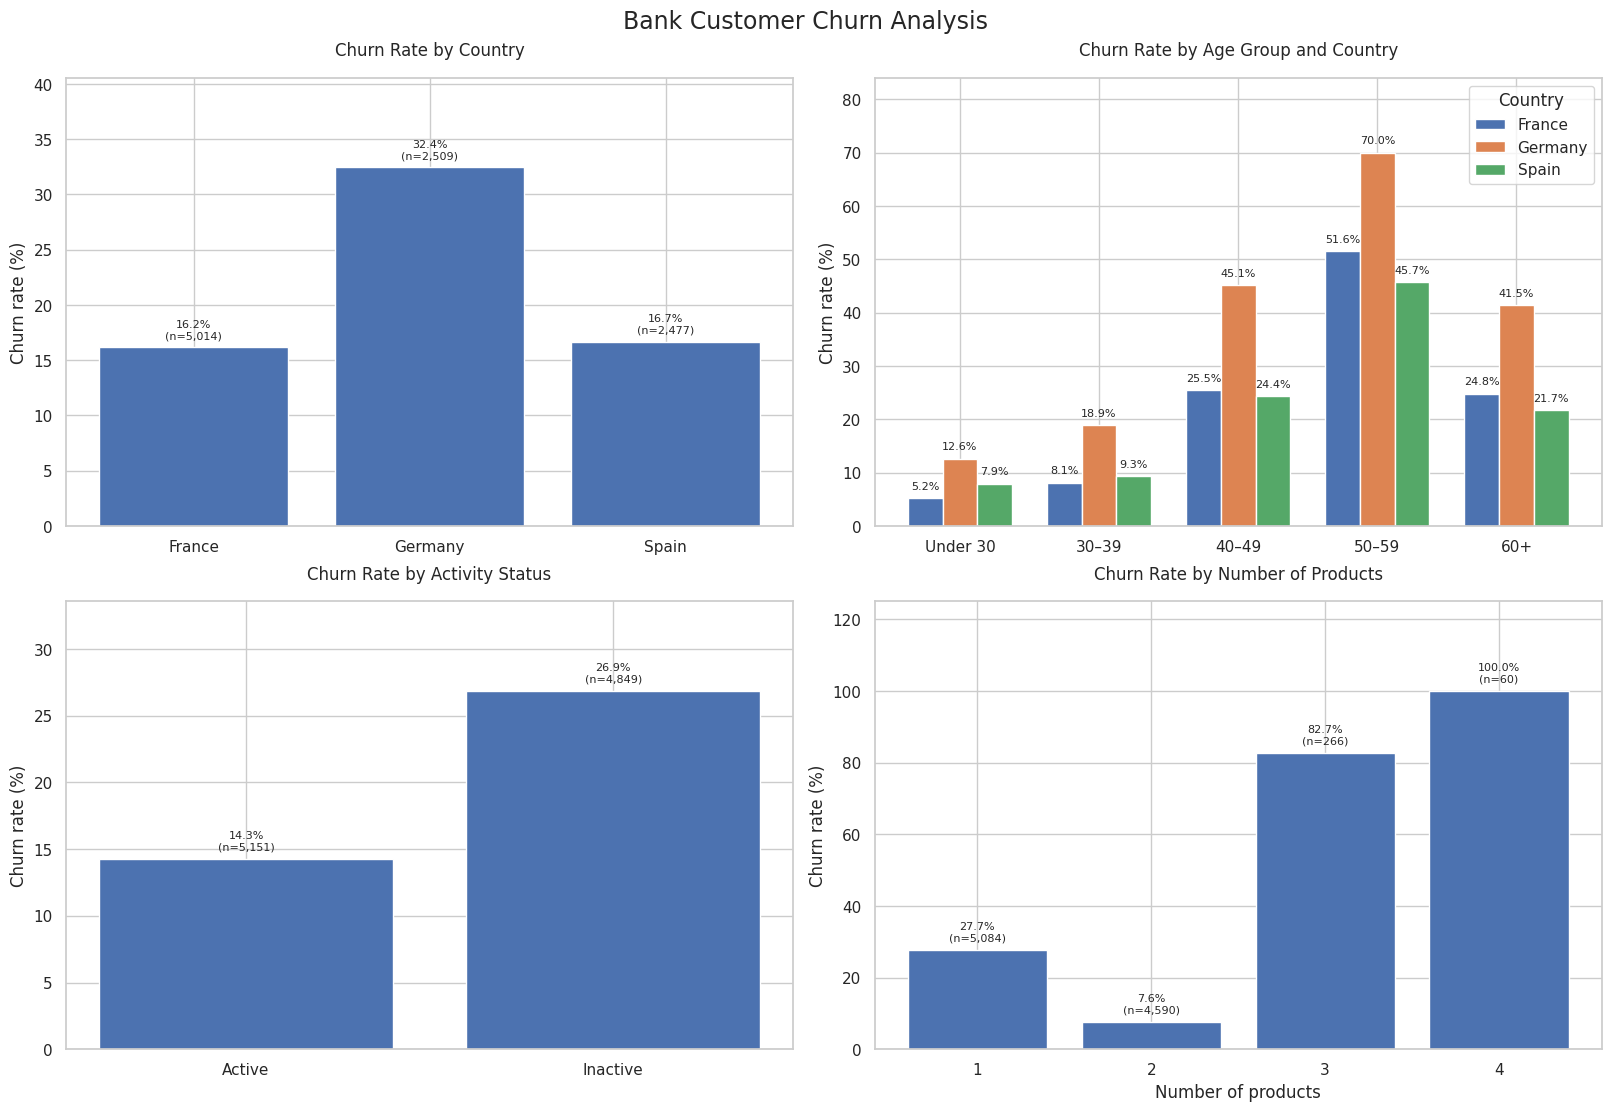

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create age groups
df["AgeBand"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, float("inf")],
    labels=["Under 30", "30–39", "40–49", "50–59", "60+"],
    right=False
)

# Create readable activity labels
df["ActivityStatus"] = df["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

def summarize(group_columns):
    result = (
        df.groupby(group_columns, observed=True)
          .agg(
              customers=("Exited", "size"),
              churned_customers=("Exited", "sum")
          )
          .reset_index()
    )
    result["churn_rate_pct"] = (
        result["churned_customers"] / result["customers"] * 100
    )
    return result

def label_bars(ax, bars, rates, counts, show_counts=True):
    for bar, rate, count in zip(bars, rates, counts):
        label = f"{rate:.1f}%\n(n={count:,})" if show_counts else f"{rate:.1f}%"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Summaries
country = summarize(["Geography"])
activity = summarize(["ActivityStatus"])
products = summarize(["NumOfProducts"])
age_country = summarize(["AgeBand", "Geography"])

# Consistent display order
country_order = ["France", "Germany", "Spain"]
age_order = ["Under 30", "30–39", "40–49", "50–59", "60+"]
activity_order = ["Active", "Inactive"]
product_order = sorted(products["NumOfProducts"].unique())

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
fig.suptitle("Bank Customer Churn Analysis", fontsize=17)

# 1. Churn by country
country = country.set_index("Geography").reindex(country_order).reset_index()
bars = axes[0, 0].bar(country["Geography"], country["churn_rate_pct"])
axes[0, 0].set_title("Churn Rate by Country", pad=16)
axes[0, 0].set_ylabel("Churn rate (%)")
axes[0, 0].set_ylim(0, country["churn_rate_pct"].max() * 1.25)
label_bars(
    axes[0, 0], bars,
    country["churn_rate_pct"],
    country["customers"]
)

# 2. Churn by age group and country
x = np.arange(len(age_order))
width = 0.25

for i, geography in enumerate(country_order):
    subset = (
        age_country[age_country["Geography"] == geography]
        .set_index("AgeBand")
        .reindex(age_order)
    )
    bars = axes[0, 1].bar(
        x + (i - 1) * width,
        subset["churn_rate_pct"],
        width,
        label=geography
    )
    label_bars(
        axes[0, 1], bars,
        subset["churn_rate_pct"],
        subset["customers"],
        show_counts=False
    )

axes[0, 1].set_title("Churn Rate by Age Group and Country", pad=16)
axes[0, 1].set_ylabel("Churn rate (%)")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(age_order)
axes[0, 1].set_ylim(0, age_country["churn_rate_pct"].max() * 1.2)
axes[0, 1].legend(title="Country")

# 3. Churn by activity status
activity = activity.set_index("ActivityStatus").reindex(activity_order).reset_index()
bars = axes[1, 0].bar(activity["ActivityStatus"], activity["churn_rate_pct"])
axes[1, 0].set_title("Churn Rate by Activity Status", pad=16)
axes[1, 0].set_ylabel("Churn rate (%)")
axes[1, 0].set_ylim(0, activity["churn_rate_pct"].max() * 1.25)
label_bars(
    axes[1, 0], bars,
    activity["churn_rate_pct"],
    activity["customers"]
)

# 4. Churn by number of products
products = products.set_index("NumOfProducts").reindex(product_order).reset_index()
bars = axes[1, 1].bar(
    products["NumOfProducts"].astype(str),
    products["churn_rate_pct"]
)
axes[1, 1].set_title("Churn Rate by Number of Products", pad=16)
axes[1, 1].set_xlabel("Number of products")
axes[1, 1].set_ylabel("Churn rate (%)")
axes[1, 1].set_ylim(0, products["churn_rate_pct"].max() * 1.25)
label_bars(
    axes[1, 1], bars,
    products["churn_rate_pct"],
    products["customers"]
)

plt.show()

In [20]:
import pandas as pd

url = "https://d3p662obnq9uz2.cloudfront.net/chat-uploads/chat/user/6ac546a823dd3dd3e788168d/6ac79f2f2cb40019ce0244c3/49e1dead-European_Bank.csv"

df = pd.read_csv(url)

print("Dataset size:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

for column in ["Exited", "IsActiveMember", "HasCrCard", "NumOfProducts"]:
    if column in df.columns:
        print(f"\n{column} values:")
        print(df[column].value_counts(dropna=False).sort_index())

display(df.head())


Dataset size: (10000, 14)

Columns:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Exited values:
Exited
0    7963
1    2037
Name: count, dtype: int64

IsActiveMember values:
IsActiveMember
0    4849
1    5151
Name: count, dtype: int64

HasCrCard values:
HasCrCard
0    2945
1    7055
Name: count, dtype: int64

NumOfProducts values:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
print("Unique CustomerIds:", df["CustomerId"].nunique())
print("Duplicate CustomerIds:", df["CustomerId"].duplicated().sum())

print("\nYear distribution:")
print(df["Year"].value_counts(dropna=False).sort_index())

print("\nExited values:")
print(sorted(df["Exited"].dropna().unique()))


Unique CustomerIds: 10000
Duplicate CustomerIds: 0

Year distribution:
Year
2025    10000
Name: count, dtype: int64

Exited values:
[np.int64(0), np.int64(1)]


In [22]:
import pandas as pd

# Count balance only for customers who churned
df["ChurnedBalance"] = df["Balance"].where(df["Exited"] == 1, 0)

country_finance = (
    df.groupby("Geography")
      .agg(
          customers=("CustomerId", "nunique"),
          churned_customers=("Exited", "sum"),
          total_balance=("Balance", "sum"),
          churned_balance=("ChurnedBalance", "sum")
      )
      .reset_index()
)

country_finance["churn_rate_pct"] = (
    country_finance["churned_customers"]
    / country_finance["customers"] * 100
)

country_finance["churned_balance_share_within_country_pct"] = (
    country_finance["churned_balance"]
    / country_finance["total_balance"].replace(0, pd.NA) * 100
)

country_finance["share_of_all_churned_balance_pct"] = (
    country_finance["churned_balance"]
    / country_finance["churned_balance"].sum() * 100
)

display(country_finance.round(2))


,Geography,customers,churned_customers,total_balance,churned_balance,churn_rate_pct,churned_balance_share_within_country_pct,share_of_all_churned_balance_pct
0,France,5014,810,3.113325e+08,57666164.54,16.15,18.52,31.07
1,Germany,2509,814,3.004029e+08,97973915.53,32.44,32.61,52.79
2,Spain,2477,413,1.531236e+08,29948014.56,16.67,19.56,16.14
